# **Fine tuning of set A trained model on set C for S. aureus**

## **Import the necessary libraries**

In [1]:
import os

os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"  # must be set before torch is imported
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"


In [2]:
#utilities
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from collections import defaultdict
import copy
import re
import json
import umap
import shap
from tqdm import tqdm


# data splitting, metrics calculation
from skmultilearn.model_selection import IterativeStratification
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    balanced_accuracy_score,
    hamming_loss,
    confusion_matrix
)
from sklearn.calibration import calibration_curve

# model training
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.nn import BCELoss
from torch.optim.lr_scheduler import ReduceLROnPlateau

2025-11-19 17:15:18.722921: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763572519.146104      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763572519.265598      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## **Importing torchbnn for bayesian network**

In [3]:
!pip install torchbnn
import torchbnn as bnn

## **Seed for reproducibility**

In [4]:
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)
    torch.set_float32_matmul_precision('high')


SEED = 3
seed_everything(3)

# **Utility Functions**

## **Function to make specific specie-antibiotic datasets**

This function reads a CSV file containing MALDI-TOF spectra and metadata, extracts numeric features (spectral bins), and filters the data for a specific bacterial species and selected antibiotics. It performs the following:
- Selects only rows corresponding to the target species.
- Filters out antibiotic columns that are not available or contain only NaNs.
- Combines spectral features with susceptibility labels for valid antibiotics.
- Removes rows with invalid or missing labels (only 'R', 'S', or 'I' are retained).

Returns a cleaned DataFrame ready for downstream AMR modeling.


In [5]:
def generate_driam_sets(specie, antibiotics, file_path, output_path = ""):
    """
    Extracts and prepares MALDI-TOF mass spectra and antibiotic resistance labels 
    for a given bacterial species from a DRIAM CSV file.

    Args:
        specie (str): Target bacterial species to extract.
        antibiotics (List[str]): List of antibiotic names to extract resistance labels for.
        file_path (str): Path to the input CSV file containing the DRIAM dataset.
        output_path (str, optional): Directory to save output files (not used here). Defaults to "".

    Returns:
        pd.DataFrame or None: Trimmed dataframe containing mass spectra and labels for the species.
                              Returns None if no data is found or antibiotics are missing.
    """
    print("Processing file at", file_path)
    bacteria = pd.read_csv(file_path)
    #Dropong all column with atleast one non-numeric character to Extract the feature columns i.e the bins
    malditof = bacteria[bacteria.columns.drop(list(bacteria.filter(regex='[^0-9]')))]

    print(f"\nProcessing species: {specie} in file: {file_path}")
    # We extract the species under study
    filtered_bacteria = bacteria[bacteria["species"] == specie]

    # Skip gracefully if no species are found in the file
    if filtered_bacteria.empty:
        print(f"Skipping {specie} in {file_path}: No rows found for species.")
        return

    # We'll only use those antibiotics in the given antibiotics which are actually present for that specie in dataframe
    available_antibiotics = [ab for ab in antibiotics if ab in filtered_bacteria.columns]

    # if no antibiotic is available in file, then skip gracefully
    if not available_antibiotics:
        print(f"Skipping {specie} in {file_path}: None of the specified antibiotics found.")
        return


    # If the label column cells are empty, replace them with the NaN
    filtered_bacteria[available_antibiotics] = filtered_bacteria[available_antibiotics].replace('', np.nan)

    # Drop columns that are completely NaN
    filtered_bacteria.dropna(axis=1, how='all', inplace=True)

    # Again get the available antibiotics in updated filtered dataframe where we dropped NaN columns
    available_antibiotics = [ab for ab in available_antibiotics if ab in filtered_bacteria.columns]

    # Making the new dataframes by combining mass spectra and antibiotic columns
    trimmed_bac = pd.DataFrame(
        np.column_stack([malditof.loc[filtered_bacteria.index], filtered_bacteria[available_antibiotics]]),
        columns=list(malditof.columns) + available_antibiotics
        )

    # Drop rows where any antibiotic label is NOT 'R' or 'S'
    for ab in antibiotics:
        trimmed_bac = trimmed_bac[trimmed_bac[ab].isin(['R', 'S', 'I'])]

    # Also drop rows with NaNs in antibiotic columns
    trimmed_bac = trimmed_bac.dropna(subset=antibiotics)

    # Proceed with analysis
    return trimmed_bac


## **Multi-label Stratified Train-Test Split**

This function performs a train-test split while preserving label distributions across multiple antibiotic resistance labels using `IterativeStratification`. This is crucial for multi-label classification problems, where standard stratification is not sufficient.

The number of splits is derived from the test size, and the function returns indices for training and testing data.


In [6]:
# Function to do train/test split stratified multi-label
def multilabel_train_test_split(X, y, test_size=0.2):
    """
    Performs stratified multi-label train/test split using iterative stratification.

    Args:
        X (np.ndarray): Input feature matrix.
        y (np.ndarray): Binary multi-label matrix of shape (n_samples, n_labels).
        test_size (float): Proportion of data to include in the test split.

    Returns:
        Tuple[np.ndarray, np.ndarray]: Indices for training and testing sets.
    """
    # Splitting the Multi-label dataset
    inv = 1 / test_size
    n_splits = max(2, int(round(inv)))  # Make sure it's at least 2
    stratifier = IterativeStratification(n_splits=n_splits, order=1)
    # Returning the train and test indices
    for train_idx, test_idx in stratifier.split(X, y):
        return train_idx, test_idx

## **Label Smoothing for Multi-label Targets**

Applies label smoothing to the binary ground-truth matrix. Instead of using hard 0/1 labels, the function softens them slightly to reduce overconfidence in model predictions and improve generalization.
This is particularly useful in multi-label settings with imbalanced or noisy labels.


In [7]:
# applying the label smoothing
def apply_label_smoothing(y_true, smoothing=0.1):
    """
    Applies label smoothing to binary multi-label targets.

    Args:
        y_true (np.ndarray or torch.Tensor): Ground truth binary labels.
        smoothing (float): Smoothing factor to reduce label confidence.

    Returns:
        Same type as input: Smoothed labels.
    """
    return y_true * (1.0 - smoothing) + 0.5 * smoothing

## **Custom PyTorch Dataset for Antibiotic Resistance Spectra**

This class wraps MALDI-TOF spectral features and resistance labels into a PyTorch `Dataset` for use with data loaders.  
It ensures:
- Features are 2D tensors with a channel dimension (e.g., for CNNs).
- Labels are cast to tensors and reshaped for compatibility (e.g., single-label vs. multi-label).


In [8]:
# Define a custom PyTorch dataset for antibiotic resistance classification
class AntibioticDataset(Dataset):
    """
    Custom PyTorch Dataset for antibiotic resistance classification using MALDI-TOF spectra.

    Args:
        X (np.ndarray or torch.Tensor): Input spectra of shape (N, C, L) or (N, L).
        y (np.ndarray or torch.Tensor): Binary multi-label targets of shape (N, num_labels).

    Returns:
        Tuple[torch.Tensor, torch.Tensor]: (sample, label) for each index.
    """
    def __init__(self, X, y):
        # Convert X to torch tensor with an added channel dimension if it's not already a tensor
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1) if not torch.is_tensor(X) else X

        # Convert y to torch tensor if it's not already one
        self.y = torch.tensor(y, dtype=torch.float32) if not torch.is_tensor(y) else y

    def __len__(self):
        # Return the total number of samples
        return len(self.X)

    def __getitem__(self, index):
        # Retrieve a sample and its label by index
        x = self.X[index]
        y = self.y[index]

        # Ensure scalar labels (when num_labels = 1) are returned with shape (1,)
        if len(y.shape) == 0:
            y = np.expand_dims(y, axis=0)

        return x, y


## **Prepare Year-wise Dataset Splits with Optional Label Smoothing**

This function takes in one or more dataframes containing MALDI-TOF mass spectra and resistance labels, then:
- Converts categorical resistance labels ('R', 'I', 'S') to binary values (1 for 'R' and 'I', 0 for 'S').
- Performs a multi-label stratified train/val/test split (70/10/20).
- Applies label smoothing if specified.
- Returns PyTorch `Dataset` objects for model training.

This modular setup ensures consistent, stratified splits and enables fair benchmarking.


In [9]:
from sklearn.preprocessing import Normalizer

def prepare_year_data(df_list, smooth=0, num_labels=5, split=True): 
    """
    Prepares train, validation, and test datasets from a dataframe or list of dataframes,
    or returns a complete dataset if split is False.

    Args:
        df_list (Union[pd.DataFrame, List[pd.DataFrame]]): Single dataframe or list of dataframes
            containing input features followed by label columns.
        smooth (float, optional): Label smoothing factor applied to training labels. Defaults to 0.
        num_labels (int, optional): Number of label columns at the end of the dataframe. Defaults to 5.
        split (bool, optional): Whether to split the data or not. Defaults to True.

    Returns:
        Tuple[AntibioticDataset, AntibioticDataset, AntibioticDataset] or AntibioticDataset:
            If split is True, returns a tuple of PyTorch Dataset objects:
                (train_dataset, val_dataset, test_dataset) split in a 70/10/20 ratio.
            If split is False, returns a single PyTorch Dataset object.
    """

    # Combine all dataframes if multiple are provided
    if isinstance(df_list, list):
        df = pd.concat(df_list, ignore_index=True)
    else:
        df = df_list
    
    # Split features and labels
    X = df.iloc[:, :-num_labels].values.astype(np.float32)  # Convert to float32
    y_raw = df.iloc[:, -num_labels:].values
    
    # Convert labels: 'R' and 'I' → 1, 'S' → 0
    y = ((y_raw == 'R') | (y_raw == 'I')).astype(np.float32)

    # No Split
    if not split:
        # Apply Max Normalization on the entire dataset
        normalizer = Normalizer(norm="max")
        X = normalizer.fit_transform(X)

        return AntibioticDataset(X, y)

    # Train/Val/Test Split
    # Perform 70/10/20 train/val/test multilabel split
    trainval_idx, test_idx = multilabel_train_test_split(X, y, test_size=0.2)
    X_trainval, y_trainval = X[trainval_idx], y[trainval_idx]
    train_idx, val_idx = multilabel_train_test_split(X_trainval, y_trainval, test_size=0.125)

    # Map back to global indices for val and train
    val_idx = trainval_idx[val_idx]
    train_idx = trainval_idx[train_idx]

    # Prepare final datasets
    X_train, y_train = X[train_idx], y[train_idx]
    y_train = apply_label_smoothing(y_train, smoothing=smooth)
    X_val, y_val = X[val_idx], y[val_idx]
    X_test, y_test = X[test_idx], y[test_idx]

    # Apply Max Normalization (fit only on train)
    normalizer = Normalizer(norm="max")
    X_train = normalizer.fit_transform(X_train)
    X_val = normalizer.transform(X_val)
    X_test = normalizer.transform(X_test)

    # Wrap in PyTorch Dataset objects
    train_dataset = AntibioticDataset(X_train, y_train)
    val_dataset = AntibioticDataset(X_val, y_val)
    test_dataset = AntibioticDataset(X_test, y_test)

    return train_dataset, val_dataset, test_dataset

## **Compute Sample Weights for WeightedRandomSampler**

To address class imbalance in multi-label classification, we compute per-sample weights for use in a `WeightedRandomSampler`. The weight for each sample is based on the inverse frequency of its positive labels. This helps ensure that under-represented resistance classes are more likely to be sampled during training.

Note: Unlike weighting the loss function, we use these weights in a `WeightedRandomSampler`, which rebalances the training batches by drawing more frequently from under-represented samples. This prevents the model from overfitting to majority (susceptible) classes and improves generalization on rare resistance labels.


In [10]:
def compute_sample_weights(labels, smoothing=1e-5):
    """
    Computes per-sample weights for multi-label datasets based on inverse label frequency.
    Used for weighted sampling in imbalanced datasets.

    Args:
        labels (np.ndarray or torch.Tensor): Binary label matrix (N, num_labels).
        smoothing (float): Small value added to avoid division by zero.

    Returns:
        torch.DoubleTensor: Sample weights of shape (N,).
    """
    # labels: torch.Tensor or np.array of shape (N, num_labels)
    
    # Ensure labels are a NumPy array for processing
    labels = np.asarray(labels)

    # Count number of positive examples per label, add smoothing to avoid division by zero
    label_counts = labels.sum(axis=0) + smoothing

    # Compute frequency of each label
    label_freq = label_counts / labels.shape[0]

    # Inverse label frequency → rare labels get higher weight
    label_weights = 1.0 / label_freq

    # Compute sample weights:
    # For each sample, compute the sum of inverse frequencies of the positive labels
    sample_weights = (labels * label_weights).sum(axis=1)

    # Normalize by the number of positive labels per sample (to get average weight)
    sample_weights /= labels.sum(axis=1) + smoothing

    # Return weights as a torch tensor (double precision)
    return torch.DoubleTensor(sample_weights)

## **Function to analyze the class distribution**

For each sample in the dataset, the function extracts the binary resistance labels, aggregates label-wise statistics, and visualizes:

- The count of resistant and susceptible samples per antibiotic
- Resistance percentages
- A heatmap showing correlation between antibiotic resistance labels

These diagnostics are important for understanding label imbalance and co-resistance trends, which impact model training and evaluation.


In [11]:
def analyze_pytorch_dataset(dataset, label_names, name="Dataset"):
    """
    Analyzes and visualizes label distribution in a PyTorch dataset.

    Args:
        dataset (torch.utils.data.Dataset): Dataset containing MALDI-TOF spectra and labels.
        label_names (List[str]): Names of antibiotic labels.
        name (str, optional): Label for the dataset (used in plots/titles). Defaults to "Dataset".

    Returns:
        pd.DataFrame: Summary dataframe of label counts and percentages.
    """
    # Extract all data from the dataset
    all_labels = []
    for i in range(len(dataset)):
        _, labels = dataset[i]
        all_labels.append(labels.numpy())
    
    # Convert to numpy array
    y_data = np.array(all_labels)  # Shape: (n_samples, n_labels)
    
    print(f"\n{name} - Dataset Analysis:")
    print(f"Total samples: {len(dataset)}")
    print(f"Number of labels: {len(label_names)}")
    print(f"Label shape: {y_data.shape}")
    
    print(f"\n{name} - Class Distribution:")
    
    # Calculate counts for each label separately
    pos_counts = []
    neg_counts = []
    pos_percentages = []
    
    for i in range(len(label_names)):
        pos_count = int(y_data[:, i].sum())  # Count of 1s for this label
        neg_count = len(dataset) - pos_count  # Count of 0s for this label
        pos_percentage = (pos_count / len(dataset)) * 100
        
        pos_counts.append(pos_count)
        neg_counts.append(neg_count)
        pos_percentages.append(pos_percentage)
        
        print(f"{label_names[i]}:")
        print(f"  Resistant: {pos_count} ({pos_percentage:.1f}%)")
        print(f"  Susceptible: {neg_count} ({100-pos_percentage:.1f}%)")
        print()
    
    # Create summary dataframe
    dist_df = pd.DataFrame({
        'Label': label_names,
        'Resistant': pos_counts,
        'Susceptible': neg_counts,
        'Resistance %': [round(p, 2) for p in pos_percentages]
    })
    print("Summary Table:")
    print(dist_df)
    print()
    
    # Bar plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Stacked bar plot
    x_pos = np.arange(len(label_names))
    ax1.bar(x_pos, neg_counts, label='Susceptible', color='lightblue')
    ax1.bar(x_pos, pos_counts, bottom=neg_counts, label='Resistant', color='salmon')
    ax1.set_xlabel('Antibiotics')
    ax1.set_ylabel('Count')
    ax1.set_title(f'{name} - Label Distribution')
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(label_names, rotation=45, ha='right')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Percentage plot
    ax2.bar(x_pos, pos_percentages, color='coral')
    ax2.set_xlabel('Antibiotics')
    ax2.set_ylabel('Resistance Percentage (%)')
    ax2.set_title(f'{name} - Resistance Rates')
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(label_names, rotation=45, ha='right')
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(0, 100)
    
    # Add percentage labels on bars
    for i, v in enumerate(pos_percentages):
        ax2.text(i, v + 1, f'{v:.1f}%', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # Correlation heatmap
    if len(label_names) > 1:
        corr = np.corrcoef(y_data.T)
        plt.figure(figsize=(8, 6))
        sns.heatmap(corr, annot=True, cmap="coolwarm", square=True, 
                   xticklabels=label_names, yticklabels=label_names,
                   vmin=-1, vmax=1)
        plt.title(f'{name} - Label Correlation Matrix')
        plt.tight_layout()
        plt.show()
    
    return dist_df  # Return the summary for comparison

## **Multi-Head Convolutional Neural Network (1D)**

This CNN-based architecture is designed for multi-label classification from 1D input signals (e.g., time series or genomic profiles). It consists of four convolutional blocks with residual connections, followed by fully connected layers. The final representation is passed through multiple independent output heads, each predicting the probability of a binary class (e.g., resistance for each antibiotic).

A skip connection from early features is fused into the final convolutional block to retain low-level spatial information. This design improves gradient flow and representation capacity across layers.

Each output head uses a sigmoid activation to enable independent label prediction, suitable for multi-label tasks with highly imbalanced class distributions.


In [12]:
class MultiHeadCNN(nn.Module):
    """
    A multi-head convolutional neural network for multi-label classification 
    of MALDI-TOF spectra. Each output head predicts one antibiotic label.

    Args:
        num_labels (int): Number of labels to predict (i.e., antibiotics).
        input_channels (int): Number of input channels (typically 1 for mass spectra).
        dropout (float): Dropout rate for regularization.
        input_length (int): Length of the input 1D spectrum.

    Returns:
        torch.Tensor: Predictions of shape (batch_size, num_labels), with sigmoid outputs.
    """
    def __init__(self, num_labels: int, input_channels: int = 1, dropout=0.65, input_length: int = 6000):
        super(MultiHeadCNN, self).__init__()
        self.num_labels = num_labels

        # Conv Block 1
        self.conv1 = nn.Conv1d(input_channels, 128, kernel_size=17, padding=8)
        self.bn1 = nn.BatchNorm1d(128)

        # Conv Block 2
        self.conv2 = nn.Conv1d(128, 256, kernel_size=9, padding=4)
        self.bn2 = nn.BatchNorm1d(256)
        self.shortcut2 = nn.Conv1d(128, 256, kernel_size=1)

        # Conv Block 3
        self.conv3 = nn.Conv1d(256, 512, kernel_size=5, padding=2)
        self.bn3 = nn.BatchNorm1d(512)
        self.shortcut3 = nn.Conv1d(256, 512, kernel_size=1)

        # Conv Block 4
        self.conv4 = nn.Conv1d(512, 512, kernel_size=5, padding=2)
        self.bn4 = nn.BatchNorm1d(512)
        self.shortcut4 = nn.Identity()

        # Deterministic Downsampler (Conv1d with stride)
        self.downsample_long_skip = nn.Conv1d(128, 512, kernel_size=3, stride=4, padding=1)

        # Pooling
        self.pool = nn.MaxPool1d(kernel_size=2)  # deterministic

        # Output size after 4 poolings
        conv_out_length = input_length // (2 ** 4)
        self.flatten_dim = 512 * conv_out_length

        #Three fully connected layers
        self.fc1 = nn.Linear(self.flatten_dim, 512)
        self.dropout1 = nn.Dropout(dropout)

        self.fc2 = nn.Linear(512, 128)
        self.fc3 = nn.Linear(128, 128)

        # Multi-head output: one sigmoid output per label (binary classification per label)
        self.heads = nn.ModuleList([nn.Linear(128, 1) for _ in range(num_labels)])

    def forward(self, x):
        # Block 1
        x1 = F.relu(self.bn1(self.conv1(x)))
        x1_p = self.pool(x1)

        # Block 2
        x2 = F.relu(self.bn2(self.conv2(x1_p) + self.shortcut2(x1_p)))
        x2_p = self.pool(x2)

        # Block 3
        x3 = F.relu(self.bn3(self.conv3(x2_p) + self.shortcut3(x2_p)))
        x3_p = self.pool(x3)

        # Long skip connection from early features (x1) to final block,
        # downsampled to match final feature map resolution for additive fusion
        long_skip_feat = self.downsample_long_skip(x1_p)

        # Block 4
        x4 = F.relu(self.bn4(self.conv4(x3_p) + self.shortcut4(x3_p) + long_skip_feat))
        x4_p = self.pool(x4)

        # Flatten + FC
        x_flat = x4_p.view(x4_p.size(0), -1)
        x = self.dropout1(F.relu(self.fc1(x_flat)))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))

        outputs = [torch.sigmoid(head(x)) for head in self.heads]
        return torch.cat(outputs, dim=1)


## **Bayesian model for estimating uncertainty**

In [13]:
# ---- STEP 2: Replace last layers with Bayesian layers ----
class BayesMultiHeadCNN(MultiHeadCNN):
    def __init__(self, num_labels: int, bayesian_layers = 1, input_channels: int = 1, dropout=0.65, input_length: int = 6000):
        super(BayesMultiHeadCNN, self).__init__(num_labels, input_channels, dropout, input_length)

        if bayesian_layers == 1:
            self.head = bnn.BayesLinear(prior_mu=0, prior_sigma=0.3, in_features=128, out_features=num_labels)
        elif bayesian_layers == 2:
            self.fc3 = bnn.BayesLinear(prior_mu=0, prior_sigma=0.05, in_features=128, out_features=128)
            self.head = bnn.BayesLinear(prior_mu=0, prior_sigma=0.3, in_features=128, out_features=num_labels)
            

## **Define the class for running the experiment for deterministic model**

The StandardExperimentRunner class provides a modular pipeline to train and validate PyTorch models using weighted sampling, learning rate scheduling, early stopping, and loss/accuracy visualization.

In [14]:
class StandardExperimentRunner:
    def __init__(self, model, train_dataset, val_dataset, device='cuda'):
        self.model = model.to(device)
        self.device = device
        
        self.train_dataset = train_dataset
        self.val_dataset = val_dataset
    
    def train(self, 
              epochs=40, 
              batch_size=64, 
              lr=1e-4, 
              weight_decay=1e-5, 
              patience=4, 
              save_path="best_model.pt"):

        """Train the model with given hyperparametres

        Takes:
        1. epochs : No. of epochs
        2. batch_size : batch_size
        3. lr: learning rate
        4. regularization strength : weight_decay
        5. patience : learning rate schedular and early stopping patience
        6. save_path : path to save best model weights

        returns: 
        1. Trained model
        2. train_losses : list of training losses
        3. validation losses: list of validation losses
        """
        
        # set seed for generator
        g = torch.Generator()
        g.manual_seed(0)
        #compute the label weights for samples using the compute_sample_weight function defined above
        sample_weights = compute_sample_weights([label for _, label in self.train_dataset])
        #using weighted random sampler to sample the batches
        sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), generator=g, replacement=True)
        # train dataloader samples the batches using weighted random sampler to ensure that batches are not dominated by majority labels
        train_loader = DataLoader(self.train_dataset, batch_size=batch_size, sampler=sampler, shuffle=False)
        # Dataloader for validation set
        val_loader = DataLoader(self.val_dataset, batch_size=batch_size, shuffle=False)
        
        # Set up optimizer, loss, and LR scheduler
        optimizer = Adam(self.model.parameters(), lr=lr, weight_decay=weight_decay)
        criterion = nn.BCELoss()
        scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=4, verbose=True)

        # initializing variables for storing model weights
        best_val_loss = float('inf')
        best_model_wts = copy.deepcopy(self.model.state_dict())
        epochs_no_improve = 0
        
        # Track metrics
        train_losses, val_losses = [], []

        #outer loop for epoch
        for epoch in range(epochs):
            # Training phase
            self.model.train()
            #initializing losses
            epoch_train_loss = 0.0
            num_train_batches = 0

            # start training on btach
            for xb, yb in train_loader:
                #get features and targets
                xb, yb = xb.to(self.device), yb.to(self.device)
                #reset the optimizer
                optimizer.zero_grad()
                #forward pass
                out = self.model(xb)
                #calculate the loss
                loss = criterion(out, yb)
                #backward pass
                loss.backward()
                #update the weights
                optimizer.step()

                # running sum of training loss
                epoch_train_loss += loss.item()
                # maintaing the number of batches trained
                num_train_batches += 1

            # calculate average train loss
            epoch_train_loss /= num_train_batches
            # store the epoch loss
            train_losses.append(epoch_train_loss)
            
            # Validation phase
            self.model.eval()
            #initializing losses
            epoch_val_loss = 0.0
            num_val_batches = 0

            # Disable the gradient
            with torch.no_grad():
                for xb, yb in val_loader:
                    #get features and targets
                    xb, yb = xb.to(self.device), yb.to(self.device)
                    # forward pass
                    out = self.model(xb)
                    # calculate loss
                    loss = criterion(out, yb)

                    # running sum of training loss and accuracy
                    epoch_val_loss += loss.item()
                    # maintaing the number of batches trained
                    num_val_batches += 1

            # calculate average validation loss
            epoch_val_loss /= num_val_batches
            # store the epoch loss and accuracy
            val_losses.append(epoch_val_loss)

            # Display the loss
            print(f"Epoch {epoch+1}/{epochs} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")
            
            # Scheduler step
            scheduler.step(epoch_val_loss)
            # saving the best model weights so far and early stopping after patience value exceeds
            if epoch_val_loss < best_val_loss:
                best_val_loss = epoch_val_loss
                best_model_wts = copy.deepcopy(self.model.state_dict())
                torch.save(best_model_wts, save_path)
                print(" Best model saved.")
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= patience:
                    print(" Early stopping triggered.")
                    break
        
        # Load best weights
        self.model.load_state_dict(best_model_wts)
        
        # Plot training curves
        self.plot_training_curves(train_losses, val_losses)
        return self.model, train_losses, val_losses



    def plot_training_curves(self, train_losses, val_losses):
        """
        Plot training and validation loss curves over epochs.

        Parameters:
        - train_losses: List of training loss values (1 per epoch)
        - val_losses: List of validation loss values (1 per epoch)
        """

        # Define x-axis as epoch numbers starting from 1 to total number of epochs
        epochs = range(1, len(train_losses) + 1)

        # Create a figure
        plt.figure(figsize=(8, 5))

        # Plot training loss in blue
        plt.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2)

        # Plot validation loss in red
        plt.plot(epochs, val_losses, 'r-', label='Validation Loss', linewidth=2)

        # Add title and axis labels
        plt.title('Training and Validation Loss', fontsize=14, fontweight='bold')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')

        # Add legend
        plt.legend()

        # Add light grid
        plt.grid(True, alpha=0.3)

        # Adjust layout
        plt.tight_layout()

        # Show the plot
        plt.show()


        # === Print Final Training Statistics ===
        print(f"\n Final Training Metrics:")
    
        # Print last epoch's training and validation losses and accuracies
        print(f"Final Training Loss: {train_losses[-1]:.4f}")
        print(f"Final Validation Loss: {val_losses[-1]:.4f}")

        # Print best validation loss and the epoch it occurred
        best_val_loss = min(val_losses)
        best_val_loss_epoch = val_losses.index(best_val_loss) + 1
        print(f"Best Validation Loss: {best_val_loss:.4f} (Epoch {best_val_loss_epoch})")


## **Define class for running experiment on bayesian model**

In [15]:
class StandardExperimentRunner_bayesiansetup:
    def __init__(self, model, train_dataset, val_dataset, device='cuda'):
        self.model = model.to(device)
        self.device = device
        
        self.train_dataset = train_dataset
        self.val_dataset = val_dataset
    
    def train(self, 
              epochs=40, 
              batch_size=64, 
              lr=1e-4, 
              weight_decay=1e-5, 
              patience=4, 
              mc_samples = 10,
              kl_weight = 0.01,
              save_path="best_model.pt"):

        """Train the model with given hyperparametres

        Takes:
        1. epochs : No. of epochs
        2. batch_size : batch_size
        3. lr: learning rate
        4. regularization strength : weight_decay
        5. patience : learning rate schedular and early stopping patience
        6. save_path : path to save best model weights

        returns: 
        1. Trained model
        2. train_losses : list of training losses
        3. validation losses: list of validation losses
        """
        
        # set seed for generator
        g = torch.Generator()
        g.manual_seed(0)
        #compute the label weights for samples using the compute_sample_weight function defined above
        sample_weights = compute_sample_weights([label for _, label in self.train_dataset])
        #using weighted random sampler to sample the batches
        sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), generator=g, replacement=True)
        # train dataloader samples the batches using weighted random sampler to ensure that batches are not dominated by majority labels
        train_loader = DataLoader(self.train_dataset, batch_size=batch_size, sampler=sampler, shuffle=False)
        # Dataloader for validation set
        val_loader = DataLoader(self.val_dataset, batch_size=batch_size, shuffle=False)
        
        # Set up optimizer, loss, and LR scheduler
        optimizer = Adam(self.model.parameters(), lr=lr, weight_decay=weight_decay)
        # setting up binary cross entropy loss
        criterion = nn.BCELoss()
        # setting up kl-divergence term
        kl_loss = bnn.BKLLoss(reduction='mean', last_layer_only=False)
        # set up learning rate schedule
        scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=4, verbose=True)

        # initializing variables for storing model weights
        best_val_loss = float('inf')
        best_model_wts = copy.deepcopy(self.model.state_dict())
        epochs_no_improve = 0
        
        # Track metrics
        train_losses, val_losses = [], []

        #outer loop for epoch
        for epoch in range(epochs):
            # Training phase
            self.model.train()
            #initializing losses
            epoch_train_loss = 0.0
            num_train_batches = 0

            # start training on btach
            for xb, yb in train_loader:
                #get features and targets
                xb, yb = xb.to(self.device), yb.to(self.device)
                #reset the optimizer
                optimizer.zero_grad()
                #forward pass
                out = self.model(xb)
                #calculate the loss
                loss = criterion(out, yb)
                kld_loss = kl_loss(self.model)
                final_loss = loss + (kl_weight * kld_loss)
                #backward pass
                final_loss.backward()
                #update the weights
                optimizer.step()

                # running sum of training loss
                epoch_train_loss += final_loss.item()
                # maintaing the number of batches trained
                num_train_batches += 1

            # calculate average train loss
            epoch_train_loss /= num_train_batches
            # store the epoch loss
            train_losses.append(epoch_train_loss)
            
            # Validation phase
            self.model.eval()
            #initializing losses
            epoch_val_loss = 0.0
            num_val_batches = 0

            # Disable the gradient
            with torch.no_grad():
                for xb, yb in val_loader:
                    #get features and targets
                    xb, yb = xb.to(self.device), yb.to(self.device)
                    # collect MC predictions
                    preds = []
                    for _ in range(mc_samples):
                        out = self.model(xb)   # stochastic forward pass
                        preds.append(out.unsqueeze(0))  # add sample dim

                    # stack and average across MC samples
                    preds = torch.cat(preds, dim=0)           
                    out_mean = preds.mean(dim=0)              

                    # calculate loss with averaged predictions
                    loss = criterion(out_mean, yb)
                    kld_loss = kl_loss(self.model)
                    final_loss = loss + (0.01 * kld_loss)

                    # running sum of training loss and accuracy
                    epoch_val_loss += final_loss.item()
                    # maintaing the number of batches trained
                    num_val_batches += 1

            # calculate average validation loss
            epoch_val_loss /= num_val_batches
            # store the epoch loss and accuracy
            val_losses.append(epoch_val_loss)

            # Display the loss
            print(f"Epoch {epoch+1}/{epochs} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")
            
            # Scheduler step
            scheduler.step(epoch_val_loss)
            # saving the best model weights so far and early stopping after patience value exceeds
            if epoch_val_loss < best_val_loss:
                best_val_loss = epoch_val_loss
                best_model_wts = copy.deepcopy(self.model.state_dict())
                torch.save(best_model_wts, save_path)
                print(" Best model saved.")
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= patience:
                    print(" Early stopping triggered.")
                    break
        
        # Load best weights
        self.model.load_state_dict(best_model_wts)
        
        # Plot training curves
        self.plot_training_curves(train_losses, val_losses)
        return self.model, train_losses, val_losses



    def plot_training_curves(self, train_losses, val_losses):
        """
        Plot training and validation loss curves over epochs.

        Parameters:
        - train_losses: List of training loss values (1 per epoch)
        - val_losses: List of validation loss values (1 per epoch)
        """

        # Define x-axis as epoch numbers starting from 1 to total number of epochs
        epochs = range(1, len(train_losses) + 1)

        # Create a figure
        plt.figure(figsize=(8, 5))

        # Plot training loss in blue
        plt.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2)

        # Plot validation loss in red
        plt.plot(epochs, val_losses, 'r-', label='Validation Loss', linewidth=2)

        # Add title and axis labels
        plt.title('Training and Validation Loss', fontsize=14, fontweight='bold')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')

        # Add legend
        plt.legend()

        # Add light grid
        plt.grid(True, alpha=0.3)

        # Adjust layout
        plt.tight_layout()

        # Show the plot
        plt.show()


        # === Print Final Training Statistics ===
        print(f"\n Final Training Metrics:")
    
        # Print last epoch's training and validation losses and accuracies
        print(f"Final Training Loss: {train_losses[-1]:.4f}")
        print(f"Final Validation Loss: {val_losses[-1]:.4f}")

        # Print best validation loss and the epoch it occurred
        best_val_loss = min(val_losses)
        best_val_loss_epoch = val_losses.index(best_val_loss) + 1
        print(f"Best Validation Loss: {best_val_loss:.4f} (Epoch {best_val_loss_epoch})")

## **Multi-Label Model Evaluation Function**

This function `evaluate_multilabel` evaluates the trained model on a multi-label classification task. It performs the following operations:

- Computes **balanced accuracy**, **AUROC**, **AUPRC**, and **weighted F1 score** for each label individually.
- Calculates the **average of these metrics** across all labels for an overall view of model performance.
- Displays **confusion matrices** for each label using heatmaps.
- Logs predictions, probabilities, true labels, and all metrics into a structured **JSON file** for reproducibility or reporting.

**Thresholding:** A fixed threshold of `0.5` is used to convert sigmoid probabilities into binary predictions.

**Logging:** The output file `evaluation_logs.json` stores full predictions and metrics, which is useful for ablation studies or debugging later.

we use this function after model training to deeply analyze how well the model performs on each class.


In [16]:
def evaluate_multilabel(model, dataloader, label_names, device='cuda', file = "logs.json"):
    """
    Evaluate a multi-label classification model using standard metrics and visualize results.

    This function computes balanced accuracy, AUROC, AUPRC, and weighted F1 score per label,
    and averages them to give an overall picture. It also plots confusion matrices and logs
    all metrics and predictions in a JSON file for further analysis or reproducibility.

    Parameters:
    - model (torch.nn.Module): Trained PyTorch model to evaluate.
    - dataloader (torch.utils.data.DataLoader): DataLoader for the validation/test set.
    - label_names (List[str]): Names of each output label for display and logging.
    - device (str): The device to run the model on (default: 'cuda').

    Outputs:
    - Prints metrics per label and mean metrics across all labels.
    - Displays confusion matrix for each label.
    - Saves metrics and predictions in `evaluation_logs.json`.
    """

    model.eval()  # Set model to evaluation mode
    all_targets, all_preds = [], []

    # Disable gradient computation to speed up evaluation
    with torch.no_grad():
        for xb, yb in dataloader:
            xb = xb.to(device)                 # Move input to device
            yb = yb.cpu().numpy()              # Move targets to CPU for metric calculation
            preds = model(xb).cpu().numpy()    # Get predicted probabilities from model

            all_targets.append(yb)
            all_preds.append(preds)

    # Stack all batches into single arrays
    y_true = np.vstack(all_targets)                     # True labels
    y_probs = np.vstack(all_preds)                      # Predicted probabilities
    y_pred = (y_probs > 0.5).astype(int)                # Threshold predictions at 0.5

    # Prepare metric containers
    num_labels = len(label_names)
    acc_scores, auc_roc_scores, auc_prc_scores, f1_scores = [], [], [], []

    print("\nPer-Label Evaluation Metrics:\n")
    for i in range(num_labels):
        # Compute metrics for each label
        acc = balanced_accuracy_score(y_true[:, i], y_pred[:, i])
        auc_roc = roc_auc_score(y_true[:, i], y_probs[:, i])
        auc_prc = average_precision_score(y_true[:, i], y_probs[:, i])
        f1 = f1_score(y_true[:, i], y_pred[:, i], average='weighted')

        # Store metrics
        acc_scores.append(acc)
        auc_roc_scores.append(auc_roc)
        auc_prc_scores.append(auc_prc)
        f1_scores.append(f1)

        # Print per-label metrics
        print(f"{label_names[i]}:")
        print(f"  Balanced Accuracy: {acc:.4f}")
        print(f"  AUROC:             {auc_roc:.4f}")
        print(f"  AUPRC:             {auc_prc:.4f}")
        print(f"  Weighted F1:       {f1:.4f}\n")

    # Print average metrics
    print("Combined (Average) Metrics:")
    print(f"Mean Balanced Accuracy: {np.mean(acc_scores):.4f}")
    print(f"Mean AUROC:             {np.mean(auc_roc_scores):.4f}")
    print(f"Mean AUPRC:             {np.mean(auc_prc_scores):.4f}")
    print(f"Mean Weighted F1:       {np.mean(f1_scores):.4f}")
    print(f"Hamming Loss:           {hamming_loss(y_true, y_pred):.4f}")

    # === Plot Confusion Matrices ===
    fig, axes = plt.subplots(1, num_labels, figsize=(4 * num_labels, 4))
    if num_labels == 1:
        axes = [axes]  # Ensure iterable for one-label case

    for i in range(num_labels):
        cm = confusion_matrix(y_true[:, i], y_pred[:, i])
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[i])
        axes[i].set_title(label_names[i])
        axes[i].set_xlabel("Predicted")
        axes[i].set_ylabel("True")

    plt.suptitle("Confusion Matrices")
    plt.tight_layout()
    plt.show()

    # === Save Evaluation Logs to JSON ===
    log_data = {
        "label_names": label_names,
        "y_true": y_true.tolist(),
        "y_pred": y_pred.tolist(),
        "y_probs": y_probs.tolist(),
        "metrics_per_label": [],
        "mean_metrics": {
            "balanced_accuracy": float(np.mean(acc_scores)),
            "auroc": float(np.mean(auc_roc_scores)),
            "auprc": float(np.mean(auc_prc_scores)),
            "weighted_f1": float(np.mean(f1_scores)),
            "hamming_loss": float(hamming_loss(y_true, y_pred))
        }
    }

    for i in range(num_labels):
        log_data["metrics_per_label"].append({
            "label": label_names[i],
            "balanced_accuracy": float(acc_scores[i]),
            "auroc": float(auc_roc_scores[i]),
            "auprc": float(auc_prc_scores[i]),
            "weighted_f1": float(f1_scores[i])
        })

    with open(file, "w") as f:
        json.dump(log_data, f, indent=4)

    return y_pred


In [17]:
def evaluate_multilabel_bayesiansetup(
    model, dataloader, label_names, mc_samples=10,
    device='cuda', file="logs.json"):
    """
    Evaluate a multi-label Bayesian model using MC-dropout sampling
    and compute per-label metrics, per-sample uncertainty, and reliability analysis.

    This function:
    - Performs multiple stochastic forward passes (MC samples)
    - Estimates predictive mean & variance per label
    - Computes balanced accuracy, AUROC, AUPRC, F1 per label
    - Computes uncertainty for TP, TN, FP, FN
    - Logs ALL per-sample predictions, probabilities, and variances to JSON
    - Returns predicted labels

    Parameters:
    - model: PyTorch model
    - dataloader: DataLoader for test/validation
    - label_names: list of label names
    - mc_samples: number of Monte-Carlo passes
    - device: 'cuda' or 'cpu'
    - file: output JSON filename

    Output:
    - Prints metrics
    - Saves detailed evaluation logs in JSON
    - Returns binary predictions (mean > 0.5)
    """

    model.eval()
    all_targets, all_preds, all_vars = [], [], []

    per_sample_logs = []   # Stores uncertainty per data sample

    with torch.no_grad():
        for xb, yb in dataloader:

            # === Move data ===
            xb = xb.to(device)
            yb = yb.cpu().numpy()

            preds = []

            # === Monte-Carlo sampling (epistemic uncertainty) ===
            for _ in range(mc_samples):
                out = model(xb)               # stochastic forward pass
                preds.append(out.unsqueeze(0))

            # Shape: [mc_samples, batch, labels]
            preds = torch.cat(preds, dim=0)

            # Predictive mean = classification probabilities
            out_mean = preds.mean(dim=0).cpu().numpy()

            # Predictive variance = uncertainty
            out_var  = preds.var(dim=0).cpu().numpy()

            # === Store per-sample logs ===
            for i in range(len(yb)):
                per_sample_logs.append({
                    "true": yb[i].tolist(),
                    "probs": out_mean[i].tolist(),
                    "pred": (out_mean[i] > 0.5).astype(int).tolist(),
                    "variance": out_var[i].tolist()
                })

            all_targets.append(yb)
            all_preds.append(out_mean)
            all_vars.append(out_var)

    # Stack full dataset 
    y_true = np.vstack(all_targets)
    y_probs = np.vstack(all_preds)
    y_pred  = (y_probs > 0.5).astype(int)
    y_vars  = np.vstack(all_vars)

    num_labels = len(label_names)

    # Metric containers
    acc_scores, auc_roc_scores, auc_prc_scores, f1_scores = [], [], [], []
    mean_vars, var_vars, unc_per_label = [], [], []

    print("\nPer-Label Evaluation Metrics\n")

    for i in range(num_labels):

        # Compute core classification metrics
        acc     = balanced_accuracy_score(y_true[:, i], y_pred[:, i])
        auc_roc = roc_auc_score(y_true[:, i], y_probs[:, i])
        auc_prc = average_precision_score(y_true[:, i], y_probs[:, i])
        f1      = f1_score(y_true[:, i], y_pred[:, i], average='weighted')

        mean_var = float(np.mean(y_vars[:, i]))
        var_var  = float(np.var(y_vars[:, i]))

        # Mask for TP/TN/FP/FN uncertainty
        tp_mask = (y_true[:, i] == 1) & (y_pred[:, i] == 1)
        tn_mask = (y_true[:, i] == 0) & (y_pred[:, i] == 0)
        fp_mask = (y_true[:, i] == 0) & (y_pred[:, i] == 1)
        fn_mask = (y_true[:, i] == 1) & (y_pred[:, i] == 0)

        # Mean uncertainty
        tp_mean_var = float(np.mean(y_vars[tp_mask, i])) if tp_mask.any() else float("nan")
        tn_mean_var = float(np.mean(y_vars[tn_mask, i])) if tn_mask.any() else float("nan")
        fp_mean_var = float(np.mean(y_vars[fp_mask, i])) if fp_mask.any() else float("nan")
        fn_mean_var = float(np.mean(y_vars[fn_mask, i])) if fn_mask.any() else float("nan")

        # Uncertainty spread (std)
        tp_std_var = float(np.std(y_vars[tp_mask, i])) if tp_mask.any() else float("nan")
        tn_std_var = float(np.std(y_vars[tn_mask, i])) if tn_mask.any() else float("nan")
        fp_std_var = float(np.std(y_vars[fp_mask, i])) if fp_mask.any() else float("nan")
        fn_std_var = float(np.std(y_vars[fn_mask, i])) if fn_mask.any() else float("nan")

        # Store
        acc_scores.append(acc)
        auc_roc_scores.append(auc_roc)
        auc_prc_scores.append(auc_prc)
        f1_scores.append(f1)
        mean_vars.append(mean_var)
        var_vars.append(var_var)

        # Save per-label uncertainty aggregates
        unc_per_label.append({
            "label": label_names[i],
            "mean_variance": mean_var,
            "variance_of_variance": var_var,
            "tp_mean_uncertainty": tp_mean_var,
            "tn_mean_uncertainty": tn_mean_var,
            "fp_mean_uncertainty": fp_mean_var,
            "fn_mean_uncertainty": fn_mean_var,
            "tp_std_uncertainty": tp_std_var,
            "tn_std_uncertainty": tn_std_var,
            "fp_std_uncertainty": fp_std_var,
            "fn_std_uncertainty": fn_std_var
        })
        # Print per-label metrics
        print(f"{label_names[i]}:")
        print(f"  Balanced Accuracy: {acc:.4f}")
        print(f"  AUROC:             {auc_roc:.4f}")
        print(f"  AUPRC:             {auc_prc:.4f}")
        print(f"  Weighted F1:       {f1:.4f}")
        print(f"  Mean variance:     {mean_var:.4f}")
        print(f"  Variance of var.:  {var_var:.4f}")
        print(f"  TP mean Uncertainty:    {tp_mean_var:.4f}")
        print(f"  TN mean Uncertainty:    {tn_mean_var:.4f}")
        print(f"  FP mean Uncertainty:    {fp_mean_var:.4f}")
        print(f"  FN mean Uncertainty:    {fn_mean_var:.4f}\n")
        print(f"  TP std Uncertainty:    {tp_std_var:.4f}")
        print(f"  TN std Uncertainty:    {tn_std_var:.4f}")
        print(f"  FP std Uncertainty:    {fp_std_var:.4f}")
        print(f"  FN std Uncertainty:    {fn_std_var:.4f}\n")

    # Prepare full log for saving
    log_data = {
        "label_names": label_names,
        "metrics_per_label": unc_per_label,
        "mean_metrics": {
            "balanced_accuracy": float(np.mean(acc_scores)),
            "auroc": float(np.mean(auc_roc_scores)),
            "auprc": float(np.mean(auc_prc_scores)),
            "weighted_f1": float(np.mean(f1_scores)),
            "hamming_loss": float(hamming_loss(y_true, y_pred))
        },
        "per_sample": per_sample_logs  # full per-sample uncertainty
    }

    with open(file, "w") as f:
        json.dump(log_data, f, indent=4)

    return y_pred


## **Function to filter out uncertain predictions**

Filters samples based on their mean predictive variance and recomputes
multi-label performance metrics on the remaining high-confidence subset.
Useful for analyzing selective prediction and how performance changes after
removing uncertain model outputs.

In [18]:
def evaluate_after_uncertainty_filter(json_path, thresholds):
    """
    Loads per-sample logs, filters predictions *per label* based on label-specific uncertainty thresholds,
    and recomputes multi-label metrics using only confident predictions.

    Parameters:
    - json_path (str): Path to the JSON file containing per-sample logs.
    - thresholds (dict): Dictionary mapping each label name to its uncertainty threshold.

    Returns:
    - new_metrics (dict): Dictionary of computed metrics for each label using confident predictions only.
    """

    # Load JSON data containing label names and per-sample predictions
    with open(json_path, "r") as f:
        data = json.load(f)

    label_names = data["label_names"]        # List of label names (e.g., antibiotics)
    samples = data["per_sample"]             # List of per-sample prediction logs

    num_labels = len(label_names)            # Total number of labels

    # Initialize containers for filtered predictions
    y_true_filtered = []                     # True labels for confident predictions
    y_probs_filtered = []                    # Predicted probabilities for confident predictions
    y_pred_filtered = []                     # Binary predictions for confident predictions
    label_indices = []                       # Label index for each confident prediction

    kept_count = 0                           # Counter for samples with at least one confident label
    total_count = len(samples)               # Total number of samples

    # Iterate over each sample to apply label-specific uncertainty filtering
    for s in samples:
        true = np.array(s["true"])           # True labels for this sample (binary vector)
        probs = np.array(s["probs"])         # Predicted probabilities for this sample
        pred = np.array(s["pred"])           # Binary predictions for this sample
        var = np.array(s["variance"])        # Variance estimates for each label in this sample

        # Create a boolean mask: keep label i if its variance <= threshold for that label
        keep_mask = np.array([
            var[i] <= thresholds.get(label_names[i], 0.0)  # Default to 0.0 if label not in thresholds
            for i in range(num_labels)
        ])

        # If at least one label is confident, retain the filtered predictions
        if keep_mask.any():
            kept_count += 1
            y_true_filtered.append(true[keep_mask])        # Keep only confident true labels
            y_probs_filtered.append(probs[keep_mask])      # Keep only confident probabilities
            y_pred_filtered.append(pred[keep_mask])        # Keep only confident binary predictions
            label_indices.extend(np.where(keep_mask)[0])   # Track which label each confident prediction belongs to

    # Print filtering summary
    print(f"Total samples: {total_count}")
    print(f"Samples with at least ONE confident label: {kept_count}")
    print(f"Completely removed samples: {total_count - kept_count}\n")

    # Flatten lists into arrays for metric computation
    y_true_filtered = np.concatenate(y_true_filtered)
    y_probs_filtered = np.concatenate(y_probs_filtered)
    y_pred_filtered = np.concatenate(y_pred_filtered)
    label_indices = np.array(label_indices)

    new_metrics = {}  # Dictionary to store metrics per label

    # Compute metrics for each label using only confident predictions
    for i, name in enumerate(label_names):
        # Find indices of confident predictions corresponding to this label
        idx = np.where(label_indices == i)[0]

        # Skip label if no confident predictions were retained
        if len(idx) == 0:
            print(f"{name}: No confident samples, skipping.\n")
            continue

        # Compute standard classification metrics
        acc = balanced_accuracy_score(y_true_filtered[idx], y_pred_filtered[idx])
        auc_roc = roc_auc_score(y_true_filtered[idx], y_probs_filtered[idx])
        auc_prc = average_precision_score(y_true_filtered[idx], y_probs_filtered[idx])
        f1 = f1_score(y_true_filtered[idx], y_pred_filtered[idx], average="weighted")

        # Store metrics in dictionary
        new_metrics[name] = {
            "Confident balanced_accuracy": acc,
            "Confident auroc": auc_roc,
            "Confident auprc": auc_prc,
            "Confident weighted_f1": f1
        }

        # Print metrics for this label
        print(f"{name}:")
        print(f"  Threshold:              {thresholds.get(name, 0.0):.4f}")
        print(f"  Confident Balanced Acc: {acc:.4f}")
        print(f"  Confident AUROC:        {auc_roc:.4f}")
        print(f"  Confident AUPRC:        {auc_prc:.4f}")
        print(f"  Confident F1:           {f1:.4f}\n")

    return new_metrics

## **Plotting the UMAPS with and without error annotation**
`extract_features(model, dataloader, device)` Extracts intermediate features from a CNN model with residual and skip connections. This function is designed to support downstream UMAP visualization of learned representations.

`plot_umap(features, labels, label_names=None)` Projects high-dimensional feature vectors into 2D space using UMAP for each label. Used to inspect class separation in learned feature space.
`plot_umap_with_error(features, labels, preds, label_names=None)` Visualizes UMAP projection with error analysis. Circles show incorrectly classified points.

In [19]:

def extract_features(model, dataloader, device):
    """
    Extracts high-level features from the model's intermediate and final layers for visualization.

    Args:
        model (torch.nn.Module): Trained CNN model with skip connections and FC layers.
        dataloader (DataLoader): PyTorch DataLoader returning (input, label) batches.
        device (torch.device): Device to run the model on ('cpu' or 'cuda').

    Returns:
        torch.Tensor: Concatenated feature vectors of shape [n_samples, feature_dim].
        torch.Tensor: Corresponding ground truth labels of shape [n_samples, n_classes].
    """
    model.eval()  # Set model to evaluation mode
    features = []
    labels = []

    with torch.no_grad():  # Disable gradient computation for speed and memory efficiency
        for xb, yb in dataloader:
            xb = xb.to(device)
            yb = yb.to(device)

            # Forward pass through Conv Block 1
            x1 = F.relu(model.bn1(model.conv1(xb)))
            x1_p = model.pool(x1)

            # Conv Block 2 with residual connection
            x2 = F.relu(model.bn2(model.conv2(x1_p) + model.shortcut2(x1_p)))
            x2_p = model.pool(x2)

            # Conv Block 3 with residual connection
            x3 = F.relu(model.bn3(model.conv3(x2_p) + model.shortcut3(x2_p)))
            x3_p = model.pool(x3)

            # Long skip connection from Block 1
            long_skip_feat = model.downsample_long_skip(x1_p)

            # Conv Block 4 with long skip and residual connection
            x4 = F.relu(model.bn4(model.conv4(x3_p) + model.shortcut4(x3_p) + long_skip_feat))
            x4_p = model.pool(x4)

            # Flatten features and pass through FC layers
            x_flat = x4_p.view(x4_p.size(0), -1)
            x = model.dropout1(F.relu(model.fc1(x_flat)))
            x = F.relu(model.fc2(x))
            x = F.relu(model.fc3(x))

            #returning the extracted features and corresponding labels
            features.append(x.cpu())
            labels.append(yb.cpu())

    return torch.cat(features), torch.cat(labels)


def plot_umap(features, labels, label_names=None, out_dir="umap_figures"):
    """
    Plots and saves UMAP visualizations of features for each label.

    Args:
        features (Tensor or ndarray): Feature matrix [n_samples, feature_dim].
        labels (ndarray): Multi-label binary matrix [n_samples, n_classes].
        label_names (List[str], optional): List of label names.
        out_dir (str): Directory where plots will be saved.
    """
    os.makedirs(out_dir, exist_ok=True)

    # UMAP dimensionality reduction
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='euclidean', random_state=42)
    embeddings = reducer.fit_transform(features)

    num_labels = labels.shape[1]

    # Define journal-compliant figure sizes (in inches)
    half_width_in = 85 / 25.4   # 85 mm -> inches
    full_width_in = 170 / 25.4  # 170 mm -> inches
    max_height_in = 225 / 25.4  # 225 mm -> inches
    fig_height_in = min(100 / 25.4, max_height_in)  # keep it reasonable, e.g., 100 mm

    for i in range(num_labels):
        pos_mask = labels[:, i] == 1
        neg_mask = labels[:, i] == 0

        abx_name = label_names[i] if label_names else f"label_{i}"
        abx_name_clean = abx_name.replace(" ", "_").replace("/", "_")

        for width, size_label in [(half_width_in, "half"), (full_width_in, "full")]:
            fig, ax = plt.subplots(figsize=(width, fig_height_in))

            ax.scatter(embeddings[neg_mask, 0], embeddings[neg_mask, 1],
                       c='lightgray', s=10, label='Susceptible')
            ax.scatter(embeddings[pos_mask, 0], embeddings[pos_mask, 1],
                       c='red', s=10, label='Resistant')

            ax.set_title(f"UMAP Projection for {abx_name}")
            ax.legend()
            ax.grid(True)

            plt.tight_layout()

            # Save as PNG
            save_path = os.path.join(out_dir, f"umap_{abx_name_clean}_{size_label}.png")
            plt.savefig(save_path, dpi=300, bbox_inches="tight")
            plt.close(fig)
            print(f"Saved: {save_path}")

def plot_umap_with_error(features, labels, preds, label_names=None, out_dir="umap_figures_error"):
    """
    Plots and saves UMAP embeddings highlighting ground truth and model errors per label.

    Args:
        features (Tensor or ndarray): Feature matrix [n_samples, feature_dim].
        labels (ndarray): Binary ground-truth matrix [n_samples, n_classes].
        preds (ndarray): Binary predictions matrix [n_samples, n_classes].
        label_names (List[str], optional): List of label names.
        out_dir (str): Directory where plots will be saved.
    """
    os.makedirs(out_dir, exist_ok=True)

    # UMAP dimensionality reduction
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
    embeddings = reducer.fit_transform(features)

    # Journal-compliant figure sizes
    half_width_in = 85 / 25.4   # 85 mm in inches
    full_width_in = 170 / 25.4  # 170 mm in inches
    max_height_in = 225 / 25.4  # 225 mm in inches
    fig_height_in = min(100 / 25.4, max_height_in)  # keep it reasonable

    for i in range(labels.shape[1]):
        abx_name = label_names[i] if label_names else f"label_{i}"
        abx_name_clean = abx_name.replace(" ", "_").replace("/", "_")

        true_susceptible = labels[:, i] == 0
        true_resistant = labels[:, i] == 1
        misclassified = preds[:, i] != labels[:, i]

        for width, size_label in [(half_width_in, "half"), (full_width_in, "full")]:
            fig, ax = plt.subplots(figsize=(width, fig_height_in))

            # Ground truth points
            ax.scatter(embeddings[true_susceptible, 0], embeddings[true_susceptible, 1],
                       c='lightgray', s=15, label='Susceptible (True)', alpha=0.7)
            ax.scatter(embeddings[true_resistant, 0], embeddings[true_resistant, 1],
                       c='red', s=15, label='Resistant (True)', alpha=0.7)

            # Misclassified overlay
            if misclassified.any():
                ax.scatter(embeddings[misclassified, 0], embeddings[misclassified, 1],
                           facecolors='none', edgecolors='black', linewidths=1.5,
                           s=200, label='Misclassified')

            error_rate = 100 * misclassified.mean()
            ax.set_title(f"{abx_name} Resistance\n(Misclassification Rate: {error_rate:.1f}%)")
            ax.legend()
            ax.grid(alpha=0.2)

            plt.tight_layout()

            # Save figure
            save_path = os.path.join(out_dir, f"umap_{abx_name_clean}_{size_label}_error.png")
            plt.savefig(save_path, dpi=300, bbox_inches="tight")
            plt.close(fig)

            print(f"Saved: {save_path}")


# **Experiment pipeline**

We have defined all the utilities for this experiment, now we conduct the experiement


## **Loading Processed DRIAMS-C Datasets for *S. aureus***

We use the `generate_driam_sets` utility to load mass spectrometry datasets for *S. aureus* from the DRIAMS-C. We remove Ceftriaxone from this experiment as it was not available in set C. Each dataset includes binarized resistance labels for the following antibiotics:

- Ciprofloxacin
- Fusidic acid
- Oxacillin
- Clindamycin

In [20]:
# Define target antibiotics for resistance profiling
antibiotics_C = ['Ciprofloxacin', 'Fusidic acid', 'Oxacillin', 'Clindamycin']
# Set target species
specie = 'Staphylococcus aureus'

sa_C_2018 = generate_driam_sets(specie, antibiotics_C, '/kaggle/input/driams-processed-set/DriamsC_2018_bin3_2000-20000.csv')

Processing file at /kaggle/input/driams-processed-set/DriamsC_2018_bin3_2000-20000.csv


Columns (6025,6026,6030,6031,6032,6033,6034,6036,6037,6038,6039,6042,6043,6044,6045,6046,6047,6049,6051,6052,6054,6055,6057) have mixed types. Specify dtype option on import or set low_memory=False.



Processing species: Staphylococcus aureus in file: /kaggle/input/driams-processed-set/DriamsC_2018_bin3_2000-20000.csv



A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


### **Preparing train, val and test split**

In [21]:
train_dataset, val_dataset, test_dataset = prepare_year_data(sa_C_2018, smooth = 0.05, num_labels=4, split = True)

### **Analyzing distribution**


Dataset - Dataset Analysis:
Total samples: 455
Number of labels: 4
Label shape: (455, 4)

Dataset - Class Distribution:
Ciprofloxacin:
  Resistant: 27 (5.9%)
  Susceptible: 428 (94.1%)

Fusidic acid:
  Resistant: 21 (4.6%)
  Susceptible: 434 (95.4%)

Oxacillin:
  Resistant: 37 (8.1%)
  Susceptible: 418 (91.9%)

Clindamycin:
  Resistant: 64 (14.1%)
  Susceptible: 391 (85.9%)

Summary Table:
           Label  Resistant  Susceptible  Resistance %
0  Ciprofloxacin         27          428          5.93
1   Fusidic acid         21          434          4.62
2      Oxacillin         37          418          8.13
3    Clindamycin         64          391         14.07



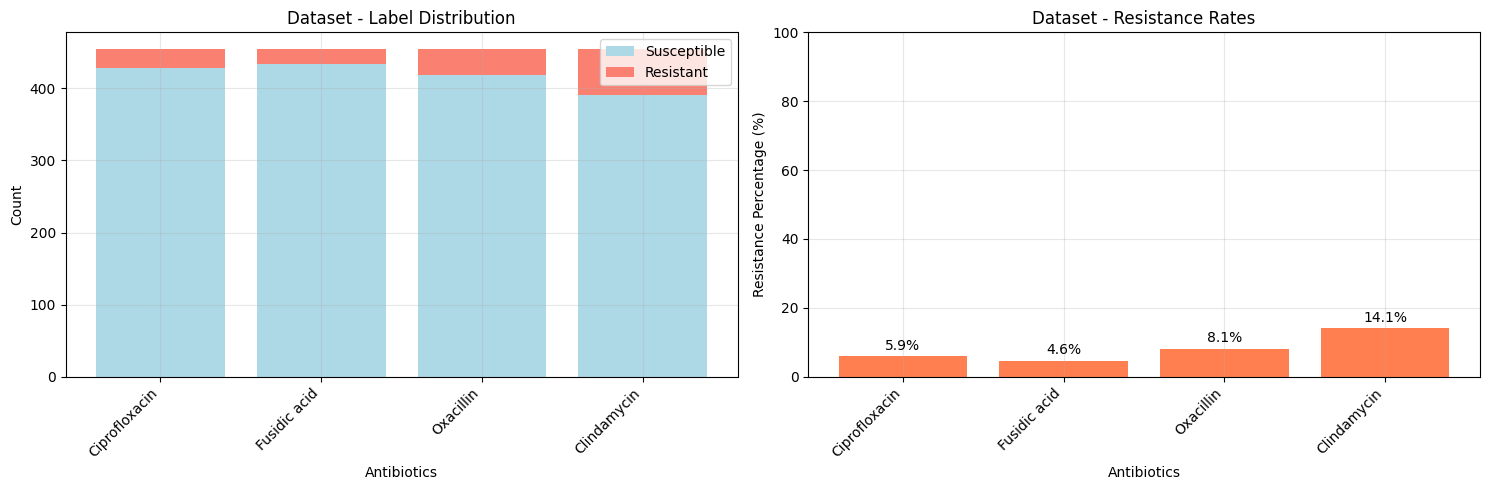

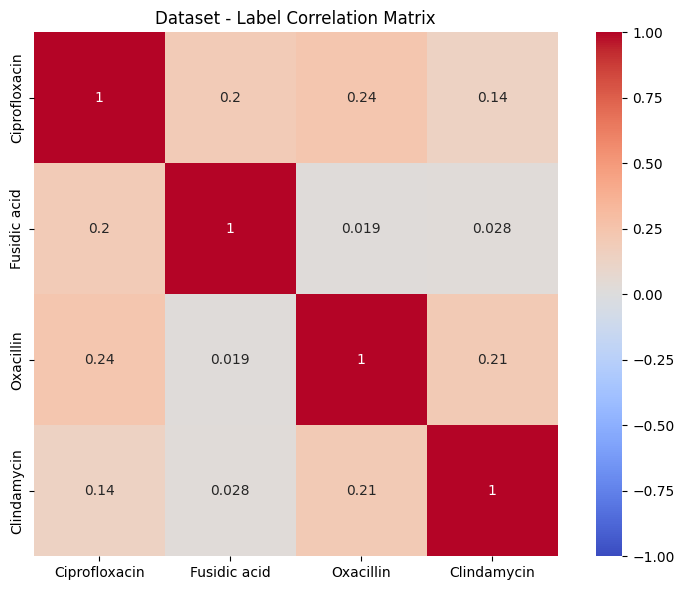


Dataset - Dataset Analysis:
Total samples: 65
Number of labels: 4
Label shape: (65, 4)

Dataset - Class Distribution:
Ciprofloxacin:
  Resistant: 3 (4.6%)
  Susceptible: 62 (95.4%)

Fusidic acid:
  Resistant: 2 (3.1%)
  Susceptible: 63 (96.9%)

Oxacillin:
  Resistant: 4 (6.2%)
  Susceptible: 61 (93.8%)

Clindamycin:
  Resistant: 8 (12.3%)
  Susceptible: 57 (87.7%)

Summary Table:
           Label  Resistant  Susceptible  Resistance %
0  Ciprofloxacin          3           62          4.62
1   Fusidic acid          2           63          3.08
2      Oxacillin          4           61          6.15
3    Clindamycin          8           57         12.31



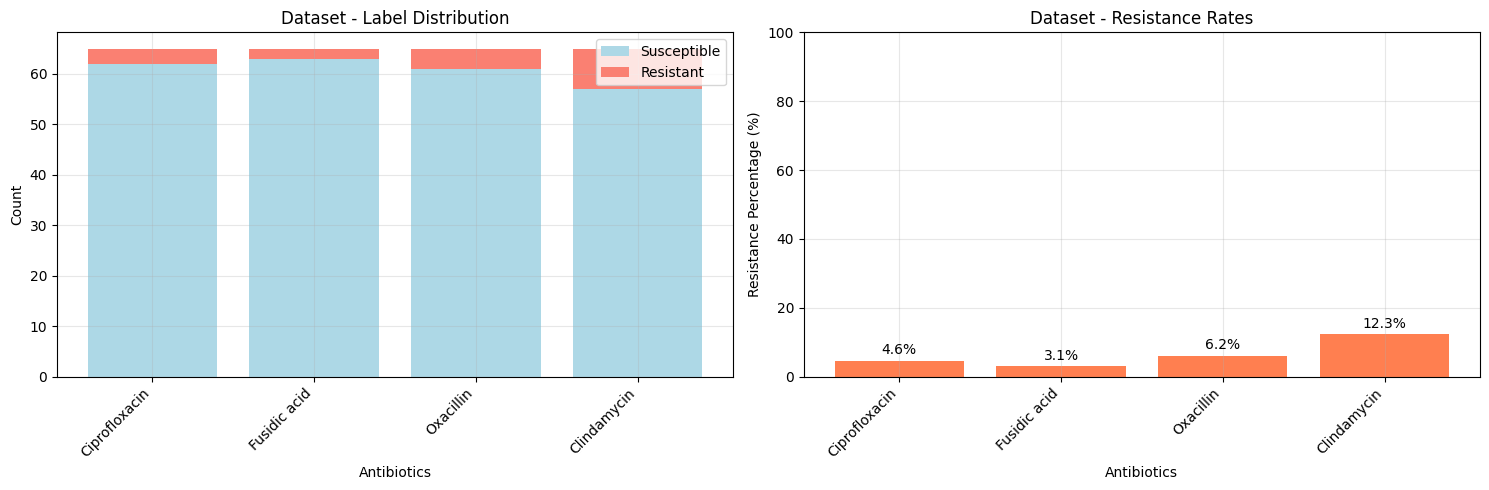

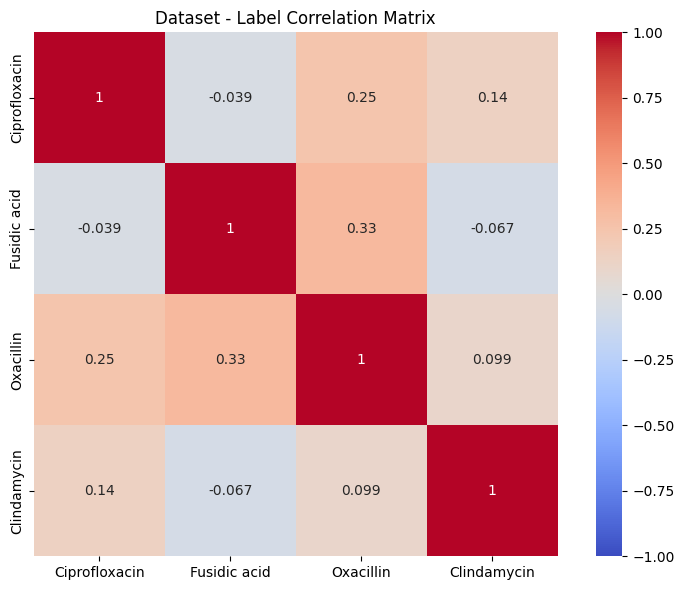


Dataset - Dataset Analysis:
Total samples: 131
Number of labels: 4
Label shape: (131, 4)

Dataset - Class Distribution:
Ciprofloxacin:
  Resistant: 5 (3.8%)
  Susceptible: 126 (96.2%)

Fusidic acid:
  Resistant: 4 (3.1%)
  Susceptible: 127 (96.9%)

Oxacillin:
  Resistant: 9 (6.9%)
  Susceptible: 122 (93.1%)

Clindamycin:
  Resistant: 15 (11.5%)
  Susceptible: 116 (88.5%)

Summary Table:
           Label  Resistant  Susceptible  Resistance %
0  Ciprofloxacin          5          126          3.82
1   Fusidic acid          4          127          3.05
2      Oxacillin          9          122          6.87
3    Clindamycin         15          116         11.45



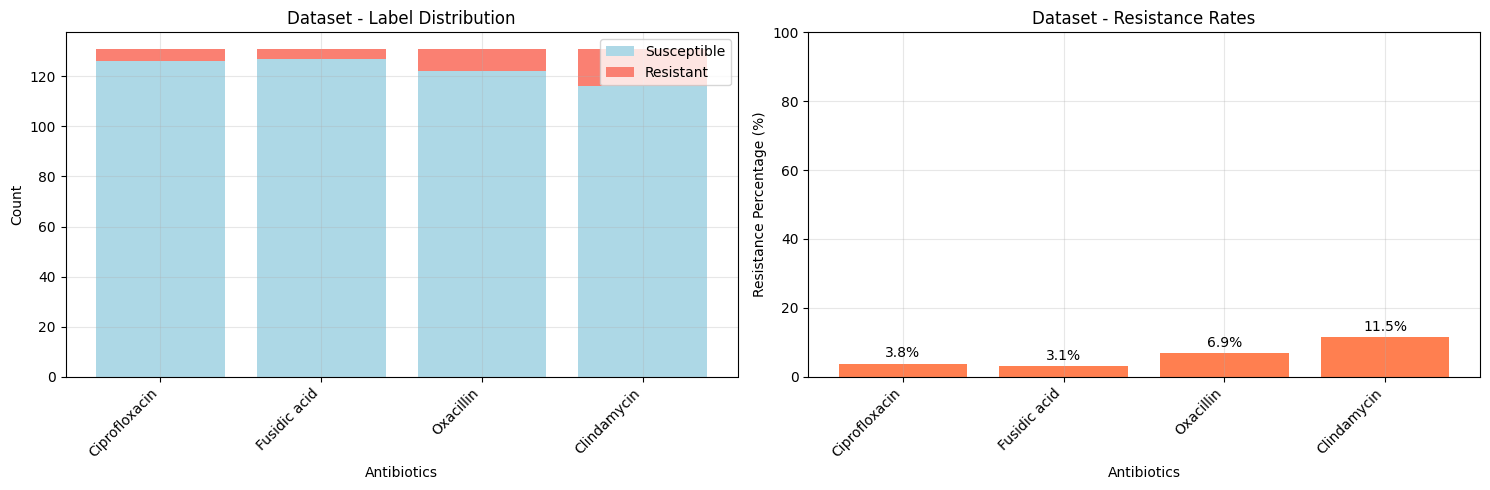

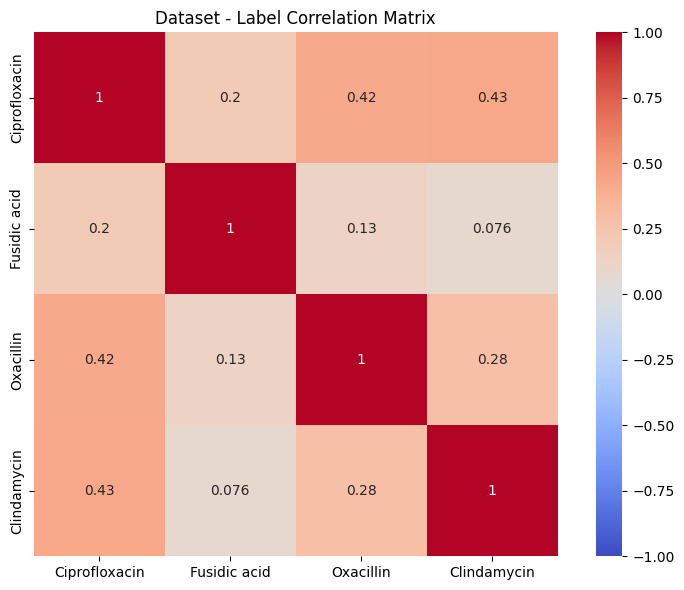

,Label,Resistant,Susceptible,Resistance %
0,Ciprofloxacin,5,126,3.82
1,Fusidic acid,4,127,3.05
2,Oxacillin,9,122,6.87
3,Clindamycin,15,116,11.45


In [22]:
analyze_pytorch_dataset(train_dataset, ['Ciprofloxacin', 'Fusidic acid', 'Oxacillin', 'Clindamycin'])
analyze_pytorch_dataset(val_dataset, ['Ciprofloxacin', 'Fusidic acid', 'Oxacillin', 'Clindamycin'])
analyze_pytorch_dataset(test_dataset, ['Ciprofloxacin', 'Fusidic acid', 'Oxacillin', 'Clindamycin'])

## **Load the deterministic set A trained model and modify the number of output heads to make it compatible for set C**

In [23]:
# Initialize model and training runner
device = "cuda" if torch.cuda.is_available() else "cpu"
model = MultiHeadCNN(num_labels=5, dropout = 0).to(device)
model.load_state_dict(torch.load("/kaggle/input/saureus-2015-2018-detmodel-seta/saureus_best_model.pt"))
# Keep only the first 4 heads
model.heads = nn.ModuleList([model.heads[i] for i in [0, 1, 2, 4]])
model.num_labels = 4  # Update internal tracking
model = model.to(device)


## **Evaluating on test set C before finetuning the deterministic model to compare performance**


Per-Label Evaluation Metrics:

Ciprofloxacin:
  Balanced Accuracy: 0.5921
  AUROC:             0.7397
  AUPRC:             0.2705
  Weighted F1:       0.9487

Fusidic acid:
  Balanced Accuracy: 0.4961
  AUROC:             0.6142
  AUPRC:             0.0511
  Weighted F1:       0.9506

Oxacillin:
  Balanced Accuracy: 0.6548
  AUROC:             0.8206
  AUPRC:             0.4572
  Weighted F1:       0.8017

Clindamycin:
  Balanced Accuracy: 0.4914
  AUROC:             0.5259
  AUPRC:             0.1377
  Weighted F1:       0.8241

Combined (Average) Metrics:
Mean Balanced Accuracy: 0.5586
Mean AUROC:             0.6751
Mean AUPRC:             0.2291
Mean Weighted F1:       0.8812
Hamming Loss:           0.1183


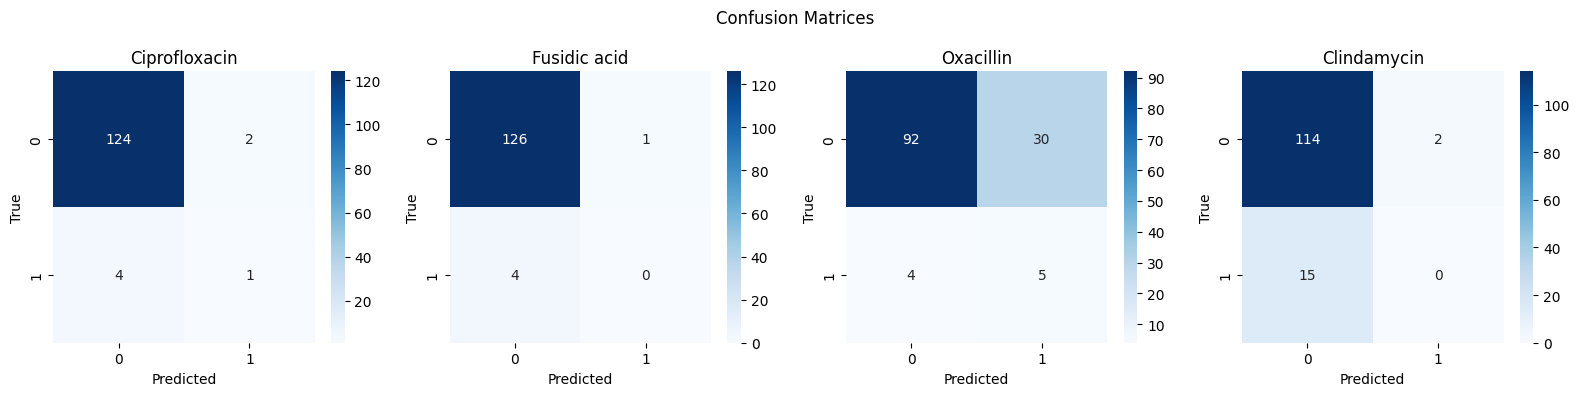

array([[0, 1, 1, 0],
       [0, 0, 0, 0],
       [0, 0, 0, 0],
       [0, 0, 0, 0],
       [0, 0, 0, 0],
       [0, 0, 1, 0],
       [0, 0, 0, 0],
       [0, 0, 0, 0],
       [1, 0, 1, 0],
       [0, 0, 0, 0],
       [0, 0, 0, 0],
       [0, 0, 0, 0],
       [0, 0, 0, 0],
       [0, 0, 0, 0],
       [0, 0, 0, 0],
       [0, 0, 0, 0],
       [0, 0, 0, 0],
       [0, 0, 0, 0],
       [0, 0, 0, 0],
       [0, 0, 0, 0],
       [0, 0, 0, 0],
       [0, 0, 0, 0],
       [0, 0, 0, 0],
       [0, 0, 0, 0],
       [0, 0, 1, 0],
       [0, 0, 0, 0],
       [0, 0, 1, 0],
       [0, 0, 1, 0],
       [0, 0, 0, 0],
       [0, 0, 0, 0],
       [0, 0, 1, 0],
       [0, 0, 0, 1],
       [0, 0, 0, 0],
       [0, 0, 0, 0],
       [0, 0, 0, 0],
       [0, 0, 1, 0],
       [0, 0, 0, 0],
       [0, 0, 1, 0],
       [0, 0, 0, 0],
       [0, 0, 1, 0],
       [0, 0, 1, 0],
       [0, 0, 1, 0],
       [0, 0, 0, 0],
       [0, 0, 0, 1],
       [0, 0, 0, 0],
       [0, 0, 0, 0],
       [0, 0, 0, 0],
       [0, 0,

In [24]:
# Evaluate on test set
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
evaluate_multilabel(model, test_loader, antibiotics_C, device="cuda", file = "sa_2015_2018_detmodel_zeroshot_setc.json")

## **Finetuning deterministic model on C train set**

The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.


Epoch 1/50 | Train Loss: 0.3514 | Val Loss: 0.1743
 Best model saved.
Epoch 2/50 | Train Loss: 0.3019 | Val Loss: 0.1720
 Best model saved.
Epoch 3/50 | Train Loss: 0.2779 | Val Loss: 0.1706
 Best model saved.
Epoch 4/50 | Train Loss: 0.2353 | Val Loss: 0.1556
 Best model saved.
Epoch 5/50 | Train Loss: 0.2456 | Val Loss: 0.1492
 Best model saved.
Epoch 6/50 | Train Loss: 0.2494 | Val Loss: 0.1622
Epoch 7/50 | Train Loss: 0.2486 | Val Loss: 0.1722
Epoch 8/50 | Train Loss: 0.2385 | Val Loss: 0.1553
Epoch 9/50 | Train Loss: 0.2088 | Val Loss: 0.1519
Epoch 10/50 | Train Loss: 0.2418 | Val Loss: 0.1580
Epoch 11/50 | Train Loss: 0.2338 | Val Loss: 0.1580
Epoch 12/50 | Train Loss: 0.2058 | Val Loss: 0.1577
Epoch 13/50 | Train Loss: 0.2336 | Val Loss: 0.1576
Epoch 14/50 | Train Loss: 0.2219 | Val Loss: 0.1575
 Early stopping triggered.


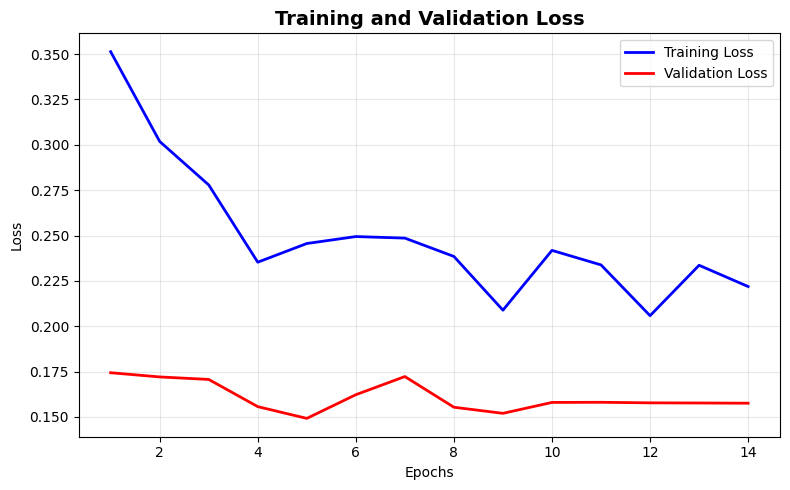


 Final Training Metrics:
Final Training Loss: 0.2219
Final Validation Loss: 0.1575
Best Validation Loss: 0.1492 (Epoch 5)


In [25]:
# Initialize model and training runner
runner = StandardExperimentRunner(model, train_dataset, val_dataset, device=device)

# Train the model
trained_det_model, train_losses, val_losses = runner.train(
        epochs=50,
        batch_size=64,
        lr=1e-5,
        weight_decay=0.00001,
        patience=9,
        save_path="best_model.pt"
)

### **Evaluating finetuned deterministic model on test set C**


Per-Label Evaluation Metrics:

Ciprofloxacin:
  Balanced Accuracy: 0.5000
  AUROC:             0.7810
  AUPRC:             0.3132
  Weighted F1:       0.9431

Fusidic acid:
  Balanced Accuracy: 0.5000
  AUROC:             0.6181
  AUPRC:             0.0541
  Weighted F1:       0.9544

Oxacillin:
  Balanced Accuracy: 0.6626
  AUROC:             0.8515
  AUPRC:             0.4967
  Weighted F1:       0.9368

Clindamycin:
  Balanced Accuracy: 0.5000
  AUROC:             0.5672
  AUPRC:             0.1757
  Weighted F1:       0.8317

Combined (Average) Metrics:
Mean Balanced Accuracy: 0.5406
Mean AUROC:             0.7045
Mean AUPRC:             0.2599
Mean Weighted F1:       0.9165
Hamming Loss:           0.0592


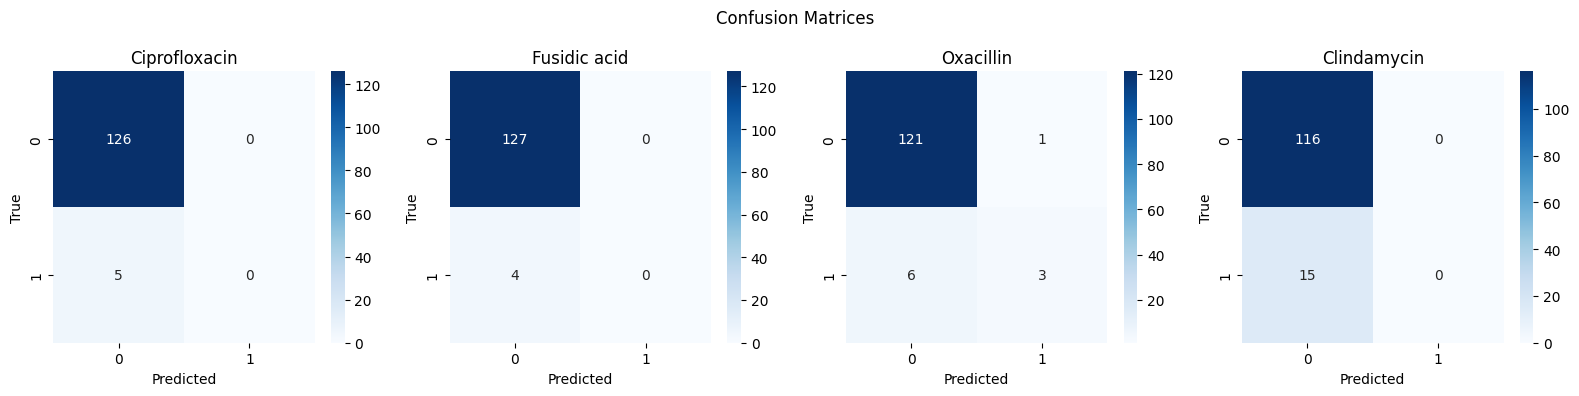

In [26]:
# Evaluate on test set
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
model.to("cuda")
preds = evaluate_multilabel(trained_det_model, test_loader, antibiotics_C, device="cuda", file = "sa_2015_2018_detmodel_finetuned_setc.json")

## **UMAPS of finetuned model with and without error annotation**

In [27]:
features, labels = extract_features(trained_det_model, test_loader, device)

# Convert to numpy
features_np = features.numpy()
labels_np = labels.numpy()

# list of label names
label_names =  ['Ciprofloxacin', 'Fusidic acid', 'Oxacillin', 'Clindamycin']
# Plot UMAP
plot_umap(features_np, labels_np, label_names=label_names, out_dir = "umap_detmodel_finetuned_setc")
plot_umap_with_error(features_np, labels_np, preds, label_names=label_names, out_dir = "umap_detmodel_finetuned_errors_setc")

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


Saved: umap_detmodel_finetuned_setc/umap_Ciprofloxacin_half.png
Saved: umap_detmodel_finetuned_setc/umap_Ciprofloxacin_full.png
Saved: umap_detmodel_finetuned_setc/umap_Fusidic_acid_half.png
Saved: umap_detmodel_finetuned_setc/umap_Fusidic_acid_full.png
Saved: umap_detmodel_finetuned_setc/umap_Oxacillin_half.png
Saved: umap_detmodel_finetuned_setc/umap_Oxacillin_full.png
Saved: umap_detmodel_finetuned_setc/umap_Clindamycin_half.png
Saved: umap_detmodel_finetuned_setc/umap_Clindamycin_full.png


n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


Saved: umap_detmodel_finetuned_errors_setc/umap_Ciprofloxacin_half_error.png
Saved: umap_detmodel_finetuned_errors_setc/umap_Ciprofloxacin_full_error.png
Saved: umap_detmodel_finetuned_errors_setc/umap_Fusidic_acid_half_error.png
Saved: umap_detmodel_finetuned_errors_setc/umap_Fusidic_acid_full_error.png
Saved: umap_detmodel_finetuned_errors_setc/umap_Oxacillin_half_error.png
Saved: umap_detmodel_finetuned_errors_setc/umap_Oxacillin_full_error.png
Saved: umap_detmodel_finetuned_errors_setc/umap_Clindamycin_half_error.png
Saved: umap_detmodel_finetuned_errors_setc/umap_Clindamycin_full_error.png


## **Load the bayesian set A trained model and modify the number of output heads to make it compatible for set C**

In [28]:
# Initialize model architecture
device = "cuda" if torch.cuda.is_available() else "cpu"
bayes_model = BayesMultiHeadCNN(bayesian_layers = 2, num_labels=5, dropout = 0)

#load the pre-trained model weights
bayes_model.load_state_dict(torch.load("/kaggle/input/saureus-2015-2018-lasttwolayersbayes-seta/best_model.pt"))

# Keep only the first 4 heads
bayes_model.heads = nn.ModuleList([bayes_model.heads[i] for i in range(4)])
bayes_model.num_labels = 4  # Update internal tracking

#move the model to cuda
bayes_model = bayes_model.to(device)

## **Evaluating on test set C before finetuning the bayesian model to compare performance**

In [29]:
# Evaluate on test set
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
preds = evaluate_multilabel_bayesiansetup(bayes_model, test_loader, antibiotics_C, device="cuda", file = "sa_2015_2018_lasttwolayerbayes_setc_zeroshot_run1.json")
preds = evaluate_multilabel_bayesiansetup(bayes_model, test_loader, antibiotics_C, device="cuda", file = "sa_2015_2018_lasttwolayerbayes_setc_zeroshot_run2.json")
preds = evaluate_multilabel_bayesiansetup(bayes_model, test_loader, antibiotics_C, device="cuda", file = "sa_2015_2018_lasttwolayerbayes_setc_zeroshot_run3.json")
preds = evaluate_multilabel_bayesiansetup(bayes_model, test_loader, antibiotics_C, device="cuda", file = "sa_2015_2018_lasttwolayerbayes_setc_zeroshot_run4.json")
preds = evaluate_multilabel_bayesiansetup(bayes_model, test_loader, antibiotics_C, device="cuda", file = "sa_2015_2018_lasttwolayerbayes_setc_zeroshot_run5.json")


Per-Label Evaluation Metrics

Ciprofloxacin:
  Balanced Accuracy: 0.5960
  AUROC:             0.7635
  AUPRC:             0.3326
  Weighted F1:       0.9539
  Mean variance:     0.0195
  Variance of var.:  0.0008
  TP mean Uncertainty:    0.0798
  TN mean Uncertainty:    0.0172
  FP mean Uncertainty:    0.0907
  FN mean Uncertainty:    0.0593

  TP std Uncertainty:    0.0000
  TN std Uncertainty:    0.0256
  FP std Uncertainty:    0.0000
  FN std Uncertainty:    0.0469

Fusidic acid:
  Balanced Accuracy: 0.5000
  AUROC:             0.6850
  AUPRC:             0.0636
  Weighted F1:       0.9544
  Mean variance:     0.0140
  Variance of var.:  0.0004
  TP mean Uncertainty:    nan
  TN mean Uncertainty:    0.0136
  FP mean Uncertainty:    nan
  FN mean Uncertainty:    0.0262

  TP std Uncertainty:    nan
  TN std Uncertainty:    0.0188
  FP std Uncertainty:    nan
  FN std Uncertainty:    0.0158

Oxacillin:
  Balanced Accuracy: 0.7577
  AUROC:             0.8424
  AUPRC:             0.51

## **Finetuning the bayesian model**

The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.


Epoch 1/50 | Train Loss: 0.4594 | Val Loss: 0.1538
 Best model saved.
Epoch 2/50 | Train Loss: 0.4637 | Val Loss: 0.1675
Epoch 3/50 | Train Loss: 0.4043 | Val Loss: 0.1592
Epoch 4/50 | Train Loss: 0.2742 | Val Loss: 0.1532
 Best model saved.
Epoch 5/50 | Train Loss: 0.3049 | Val Loss: 0.1532
 Best model saved.
Epoch 6/50 | Train Loss: 0.3006 | Val Loss: 0.1481
 Best model saved.
Epoch 7/50 | Train Loss: 0.2973 | Val Loss: 0.1738
Epoch 8/50 | Train Loss: 0.2727 | Val Loss: 0.1967
Epoch 9/50 | Train Loss: 0.2515 | Val Loss: 0.1568
Epoch 10/50 | Train Loss: 0.3126 | Val Loss: 0.1503
Epoch 11/50 | Train Loss: 0.2670 | Val Loss: 0.1599
Epoch 12/50 | Train Loss: 0.2481 | Val Loss: 0.1576
Epoch 13/50 | Train Loss: 0.2610 | Val Loss: 0.1761
Epoch 14/50 | Train Loss: 0.2613 | Val Loss: 0.1641
Epoch 15/50 | Train Loss: 0.3040 | Val Loss: 0.1646
 Early stopping triggered.


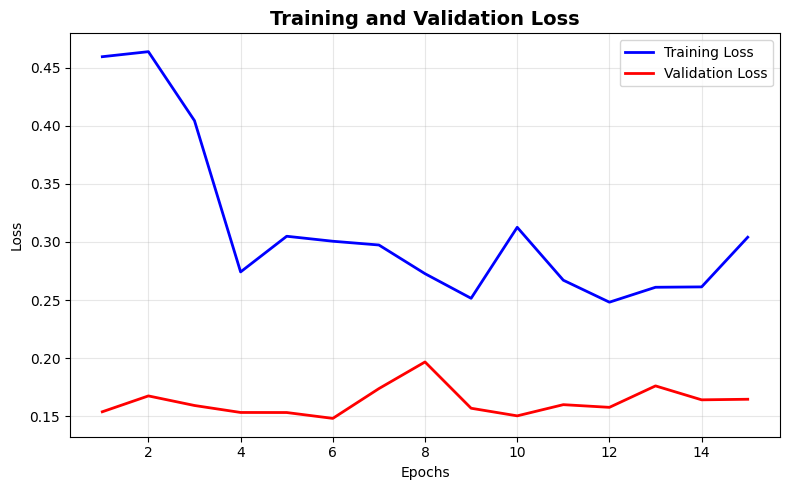


 Final Training Metrics:
Final Training Loss: 0.3040
Final Validation Loss: 0.1646
Best Validation Loss: 0.1481 (Epoch 6)


In [30]:
device = "cuda" if torch.cuda.is_available() else "cpu"
runner = StandardExperimentRunner_bayesiansetup(bayes_model, train_dataset, val_dataset, device=device)

# Train the model
trained_bayes_model, train_losses, val_losses = runner.train(
        epochs=50,
        batch_size=64,
        lr=1e-5,
        weight_decay=0.00001,
        patience=9,
        kl_weight = 0.01,
        save_path="best_model_bayes.pt"
)

## **Evaluating bayesian model after finetuning on set c**

In [31]:
preds = evaluate_multilabel_bayesiansetup(trained_bayes_model, test_loader, antibiotics_C, device="cuda", file = "sa_2015_2018_lasttwolayerbayes_setc_finetuned_run1.json")
preds = evaluate_multilabel_bayesiansetup(trained_bayes_model, test_loader, antibiotics_C, device="cuda", file = "sa_2015_2018_lasttwolayerbayes_setc_finetuned_run2.json")
preds = evaluate_multilabel_bayesiansetup(trained_bayes_model, test_loader, antibiotics_C, device="cuda", file = "sa_2015_2018_lasttwolayerbayes_setc_finetuned_run3.json")
preds = evaluate_multilabel_bayesiansetup(trained_bayes_model, test_loader, antibiotics_C, device="cuda", file = "sa_2015_2018_lasttwolayerbayes_setc_finetuned_run4.json")
preds = evaluate_multilabel_bayesiansetup(trained_bayes_model, test_loader, antibiotics_C, device="cuda", file = "sa_2015_2018_lasttwolayerbayes_setc_finetuned_run5.json")


Per-Label Evaluation Metrics

Ciprofloxacin:
  Balanced Accuracy: 0.5000
  AUROC:             0.7857
  AUPRC:             0.3658
  Weighted F1:       0.9431
  Mean variance:     0.0089
  Variance of var.:  0.0001
  TP mean Uncertainty:    nan
  TN mean Uncertainty:    0.0085
  FP mean Uncertainty:    nan
  FN mean Uncertainty:    0.0174

  TP std Uncertainty:    nan
  TN std Uncertainty:    0.0100
  FP std Uncertainty:    nan
  FN std Uncertainty:    0.0161

Fusidic acid:
  Balanced Accuracy: 0.5000
  AUROC:             0.6201
  AUPRC:             0.0575
  Weighted F1:       0.9544
  Mean variance:     0.0040
  Variance of var.:  0.0000
  TP mean Uncertainty:    nan
  TN mean Uncertainty:    0.0040
  FP mean Uncertainty:    nan
  FN mean Uncertainty:    0.0042

  TP std Uncertainty:    nan
  TN std Uncertainty:    0.0067
  FP std Uncertainty:    nan
  FN std Uncertainty:    0.0027

Oxacillin:
  Balanced Accuracy: 0.5515
  AUROC:             0.8770
  AUPRC:             0.4661
  Weighte

## **Filter Out uncertain predictions annd compute confident metrics**

To demonstrate the usefulness of uncertainty signal, we select the first run. We set the uncertainty threshold tailored for each antibiotic and then filter out the samples based on those threshold to see the performance difference.

In [32]:

thresholds = {
    'Ciprofloxacin': 0.05,
    'Fusidic acid': 0.03,
    'Oxacillin': 0.04,
    'Clindamycin' : 0.02
    
}

new_metrics = evaluate_after_uncertainty_filter("/kaggle/working/sa_2015_2018_lasttwolayerbayes_setc_finetuned_run1.json", thresholds=thresholds)

Total samples: 131
Samples with at least ONE confident label: 131
Completely removed samples: 0

Ciprofloxacin:
  Threshold:              0.0500
  Confident Balanced Acc: 0.5000
  Confident AUROC:        0.7952
  Confident AUPRC:        0.4039
  Confident F1:           0.9422

Fusidic acid:
  Threshold:              0.0300
  Confident Balanced Acc: 0.5000
  Confident AUROC:        0.6351
  Confident AUPRC:        0.0658
  Confident F1:           0.9534

Oxacillin:
  Threshold:              0.0400
  Confident Balanced Acc: 0.5556
  Confident AUROC:        0.8834
  Confident AUPRC:        0.5463
  Confident F1:           0.9148

Clindamycin:
  Threshold:              0.0200
  Confident Balanced Acc: 0.5385
  Confident AUROC:        0.5836
  Confident AUPRC:        0.2499
  Confident F1:           0.8563



## **Umaps**

In [33]:
features, labels = extract_features(trained_bayes_model, test_loader, device)

# Convert to numpy
features_np = features.numpy()
labels_np = labels.numpy()

# list of label names
label_names = ['Ciprofloxacin', 'Fusidic acid', 'Oxacillin', 'Clindamycin']
# Plot UMAP
plot_umap(features_np, labels_np, label_names=label_names, out_dir = "umap_bayesmodel_finetuned_setc")
plot_umap_with_error(features_np, labels_np, preds, label_names=label_names, out_dir = "umap_bayesmodel_finetuned_errors_setc")

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


Saved: umap_bayesmodel_finetuned_setc/umap_Ciprofloxacin_half.png
Saved: umap_bayesmodel_finetuned_setc/umap_Ciprofloxacin_full.png
Saved: umap_bayesmodel_finetuned_setc/umap_Fusidic_acid_half.png
Saved: umap_bayesmodel_finetuned_setc/umap_Fusidic_acid_full.png
Saved: umap_bayesmodel_finetuned_setc/umap_Oxacillin_half.png
Saved: umap_bayesmodel_finetuned_setc/umap_Oxacillin_full.png
Saved: umap_bayesmodel_finetuned_setc/umap_Clindamycin_half.png
Saved: umap_bayesmodel_finetuned_setc/umap_Clindamycin_full.png


n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


Saved: umap_bayesmodel_finetuned_errors_setc/umap_Ciprofloxacin_half_error.png
Saved: umap_bayesmodel_finetuned_errors_setc/umap_Ciprofloxacin_full_error.png
Saved: umap_bayesmodel_finetuned_errors_setc/umap_Fusidic_acid_half_error.png
Saved: umap_bayesmodel_finetuned_errors_setc/umap_Fusidic_acid_full_error.png
Saved: umap_bayesmodel_finetuned_errors_setc/umap_Oxacillin_half_error.png
Saved: umap_bayesmodel_finetuned_errors_setc/umap_Oxacillin_full_error.png
Saved: umap_bayesmodel_finetuned_errors_setc/umap_Clindamycin_half_error.png
Saved: umap_bayesmodel_finetuned_errors_setc/umap_Clindamycin_full_error.png
